In [6]:
##### FOR COMPARISON ONLY
##### Creates maps of agricultural capital stock and labor (rasters)
# uses a naive model of country-average intensities for each pixel 

import os
import pandas as pd
import geopandas as gpd
import rioxarray as rio
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from glob import glob
import rasterio
from rasterio.warp import reproject, Resampling
from matplotlib.colors import BoundaryNorm
import matplotlib.colors as mcolors
from pyproj import Transformer
from matplotlib.patches import Rectangle

In [2]:
##### Load data

# Get the current working directory
cd = os.path.dirname(os.getcwd())

# Import data
capital = rio.open_rasterio(f"{cd}/Results/Raster_model/reprojected/rescaled_capital_USD_country_avg.tif")
labor = rio.open_rasterio(f"{cd}/Results/Raster_model/reprojected/rescaled_jobs_country_avg.tif")

production = rio.open_rasterio(f"{cd}/Results/Raster_model/reprojected/total_production_tonnes_2020.tif")

country_boundaries = gpd.read_file(f"{cd}/Data/Clean/Geographies/country_geo.shp")
has_data = pd.read_csv(f'{cd}/Data/Correspondence_tables/has_data.csv')

# Set file path to figure repo
fd = "/Users/carinamanitius/Library/CloudStorage/OneDrive-UniversityofVermont/Documents/OneDrive/Dissertation/Chapter 1/Figures/RESULTS/map_capital_labor_raster/country_avg_model"

In [3]:
### Data prep

# align rasters to capital grid
target_crs = "+proj=eck4 +lon_0=0 +x_0=0 +y_0=0 +datum=WGS84 +units=m +no_defs"

capital = capital.rio.reproject(target_crs)
crs = capital.rio.crs

labor = labor.rio.reproject_match(capital)

production = production.rio.reproject_match(capital)

country_boundaries = country_boundaries.to_crs(capital.rio.crs)

# convert units 
capital_million = capital / 1e6


# identify no data countries 
country_boundaries = country_boundaries.merge(has_data, on='SHP_code', how='left')
country_boundaries['has_capital_data'] = country_boundaries['has_capital_data'].fillna(0)
country_boundaries['has_labor_data'] = country_boundaries['has_labor_data'].fillna(0)

In [4]:
##### Calculate intensity rasters 

# calculate intensities
production_masked = production.where(production >= 0.1) 
capital_intensity_USD_per_tonne = capital / production_masked
labor_intensity_thousand_jobs_per_tonne = (labor / production_masked) * 1e3

capital_intensity_USD_per_tonne = capital_intensity_USD_per_tonne.where(
    np.isfinite(capital_intensity_USD_per_tonne)
)
labor_intensity_thousand_jobs_per_tonne = labor_intensity_thousand_jobs_per_tonne.where(
    np.isfinite(labor_intensity_thousand_jobs_per_tonne)
)

# Set nodata value  
capital_intensity_USD_per_tonne = capital_intensity_USD_per_tonne.rio.write_nodata(np.nan)
labor_intensity_thousand_jobs_per_tonne = labor_intensity_thousand_jobs_per_tonne.rio.write_nodata(np.nan)

# Set CRS 
capital_intensity_USD_per_tonne = capital_intensity_USD_per_tonne.rio.write_crs(crs)
labor_intensity_thousand_jobs_per_tonne = labor_intensity_thousand_jobs_per_tonne.rio.write_crs(crs)

# Save
capital_intensity_USD_per_tonne.rio.to_raster(
    f"{cd}/Results/Raster_model/country_avg_model/capital_intensity_USD_per_tonne.tif",
    dtype="float32",
    compress="LZW"
)

labor_intensity_thousand_jobs_per_tonne.rio.to_raster(
    f"{cd}/Results/Raster_model/country_avg_model/labor_intensity_thousand_jobs_per_tonne.tif",
    dtype="float32",
    compress="LZW"
)

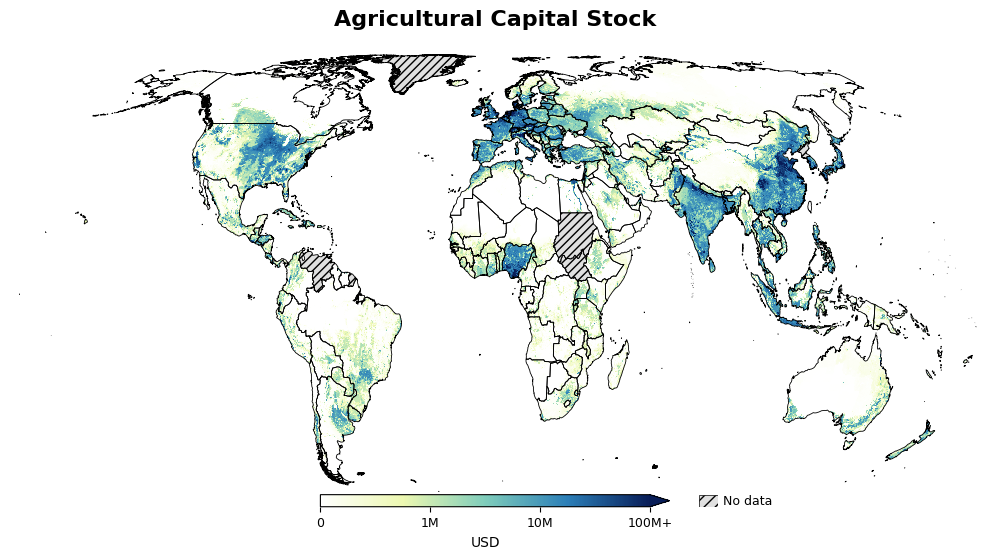

In [7]:
##### Produce global map of capital (mean estimate)

# Prepare raster
value_plot = capital.squeeze()
name = 'capital_stock'

# set custom colormap
custom_cmap = mcolors.LinearSegmentedColormap.from_list(
    "white_ylgnbu",
    ["#ffffff", "#edf8b1", "#7fcdbb", "#2c7fb8", "#081d58"]
)
custom_cmap.set_over("#081d58")  # color for the + triangle

# Set special equal-distant, manual scalling
bounds = [0, 1000000, 10000000, 100000000]      
labels = ['0', '1M', '10M', '100M+']            

positions = np.linspace(0, 1, len(bounds))  # each bound gets an equal-width slice

def forward(x):
    return np.interp(x, bounds, positions)

def inverse(x):
    return np.interp(x, positions, bounds)

norm = mcolors.FuncNorm((forward, inverse), vmin=bounds[0], vmax=bounds[-1])

# Create figure
fig, ax = plt.subplots(figsize=(10, 8))

# Countries with no data (light grey fill with hatching)
no_data_color = "#e0e0e0"
country_boundaries[country_boundaries["has_capital_data"] == 0].plot(
    ax=ax,
    facecolor=no_data_color,
    edgecolor="none",
    hatch="////",
    zorder=0
)

# Country borders
country_boundaries.plot(
    ax=ax,
    facecolor="none",
    edgecolor="black",
    linewidth=0.6,
    zorder=2
)

# Raster
im = value_plot.plot(
    ax=ax,
    cmap=custom_cmap,
    norm=norm,
    add_colorbar=False,
    add_labels=False,
    zorder=1
)

ax.set_axis_off()
ax.set_title("Agricultural Capital Stock", fontsize=16, weight='bold', pad=20)

# Generate legend 
cax = ax.inset_axes([0.32, 0.06, 0.36, 0.025], transform=ax.transAxes)

cbar = fig.colorbar(
    im,
    cax=cax,
    orientation="horizontal",
    extend='max',       
    extendfrac=0.06,    
)
cbar.set_label("USD", fontsize=10)
cbar.ax.tick_params(labelsize=9)

cbar.set_ticks(bounds)
cbar.set_ticklabels(labels)

# Add no data to legend
legend_ax = ax.inset_axes([0.71, 0.06, 0.02, 0.025], transform=ax.transAxes)
legend_ax.add_patch(Rectangle(
    (0, 0), 1, 1,
    facecolor=no_data_color,
    edgecolor="black",
    linewidth=0.5,
    hatch="///"
))
legend_ax.set_xlim(0, 1)
legend_ax.set_ylim(0, 1)
legend_ax.set_xticks([])
legend_ax.set_yticks([])
legend_ax.axis("off")

ax.text(
    0.735, 0.072, "No data",
    transform=ax.transAxes,
    fontsize=9, va="center", ha="left"
)

plt.tight_layout()
plt.show()

fig.savefig(f"{fd}/{name}.png", dpi=300, bbox_inches='tight')

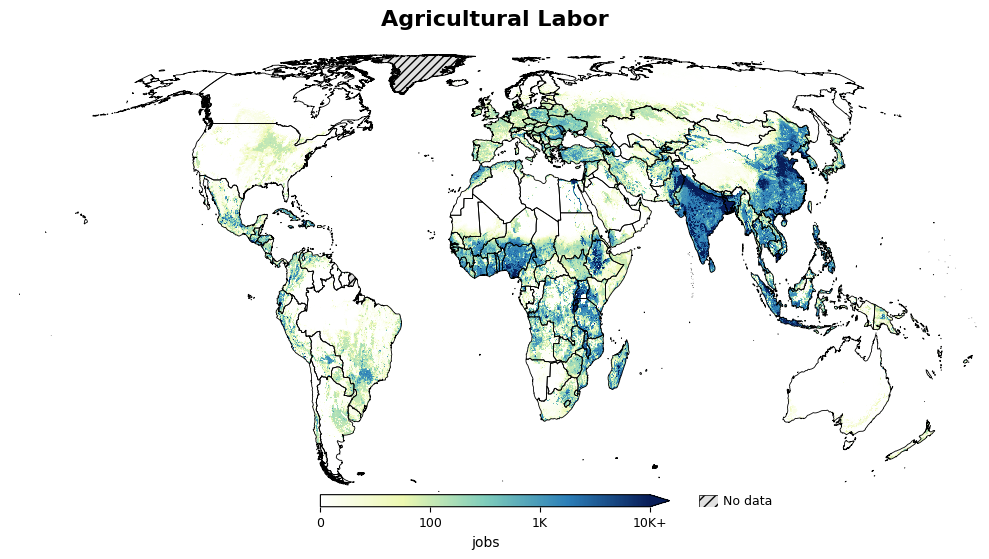

In [8]:
##### Produce global map of labor (mean estimate)

# Prepare raster
value_plot = labor.squeeze()
name = 'labor'

# set custom colormap
custom_cmap = mcolors.LinearSegmentedColormap.from_list(
    "white_ylgnbu",
    ["#ffffff", "#edf8b1", "#7fcdbb", "#2c7fb8", "#081d58"]
)
custom_cmap.set_over("#081d58")  # color for the + triangle

# Set special equal-distant, manual scalling
bounds = [0, 100, 1000, 10000]      
labels = ['0', '100', '1K', '10K+']            

positions = np.linspace(0, 1, len(bounds))  # each bound gets an equal-width slice

def forward(x):
    return np.interp(x, bounds, positions)

def inverse(x):
    return np.interp(x, positions, bounds)

norm = mcolors.FuncNorm((forward, inverse), vmin=bounds[0], vmax=bounds[-1])

# Create figure
fig, ax = plt.subplots(figsize=(10, 8))

# Countries with no data (light grey fill with hatching)
no_data_color = "#e0e0e0"
country_boundaries[country_boundaries["has_labor_data"] == 0].plot(
    ax=ax,
    facecolor=no_data_color,
    edgecolor="none",
    hatch="////",
    zorder=0
)

# Country borders
country_boundaries.plot(
    ax=ax,
    facecolor="none",
    edgecolor="black",
    linewidth=0.6,
    zorder=2
)

# Raster
im = value_plot.plot(
    ax=ax,
    cmap=custom_cmap,
    norm=norm,
    add_colorbar=False,
    add_labels=False,
    zorder=1
)

ax.set_axis_off()
ax.set_title("Agricultural Labor", fontsize=16, weight='bold', pad=20)

# Generate legend 
cax = ax.inset_axes([0.32, 0.06, 0.36, 0.025], transform=ax.transAxes)

cbar = fig.colorbar(
    im,
    cax=cax,
    orientation="horizontal",
    extend='max',       
    extendfrac=0.06,    
)
cbar.set_label("jobs", fontsize=10)
cbar.ax.tick_params(labelsize=9)

cbar.set_ticks(bounds)
cbar.set_ticklabels(labels)

# Add no data to legend
legend_ax = ax.inset_axes([0.71, 0.06, 0.02, 0.025], transform=ax.transAxes)
legend_ax.add_patch(Rectangle(
    (0, 0), 1, 1,
    facecolor=no_data_color,
    edgecolor="black",
    linewidth=0.5,
    hatch="///"
))
legend_ax.set_xlim(0, 1)
legend_ax.set_ylim(0, 1)
legend_ax.set_xticks([])
legend_ax.set_yticks([])
legend_ax.axis("off")

ax.text(
    0.735, 0.072, "No data",
    transform=ax.transAxes,
    fontsize=9, va="center", ha="left"
)

plt.tight_layout()
plt.show()

fig.savefig(f"{fd}/{name}.png", dpi=300, bbox_inches='tight')